# Exploratory Data Analysis (EDA)

Notebook **05** — explore `ckd_patients_clean.csv`.


## Section 1 — Setup and imports


In [7]:

import sys
from pathlib import Path

def project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "config.py").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Run from the GUIDAPLATE repo (config.py not found).")

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "app") not in sys.path:
    sys.path.insert(0, str(ROOT / "app"))

import config
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")

df = utils.load_csv(config.CKD_PATIENTS_CLEAN_CSV, low_memory=False)
print("Shape:", df.shape)
print(df.dtypes.to_string())
df.head()


Shape: (1769, 17)
SEQN                 float64
RIDAGEYR             float64
RIAGENDR             float64
LBXSCR               float64
eGFR                 float64
CKD_stage             object
DR1TKCAL             float64
DR1TPROT             float64
DR1TSODI             float64
DR1TPOTA             float64
DR1TPHOS             float64
DR2TKCAL             float64
DR2TPROT             float64
DR2TSODI             float64
DR2TPOTA             float64
DR2TPHOS             float64
ckd_stage_encoded      int64


,SEQN,RIDAGEYR,RIAGENDR,LBXSCR,eGFR,CKD_stage,DR1TKCAL,DR1TPROT,DR1TSODI,DR1TPOTA,DR1TPHOS,DR2TKCAL,DR2TPROT,DR2TSODI,DR2TPOTA,DR2TPHOS,ckd_stage_encoded
0,93705.0,66.0,2.0,0.92,68.671196,G2,1202.0,20.01,3574.0,1640.0,466.0,1235.0,38.52,2447.0,1158.0,738.0,1
1,93711.0,56.0,1.0,1.13,76.283182,G2,2840.0,101.33,4382.0,4457.0,2141.0,2819.0,74.81,2975.0,3345.0,1481.0,1
2,93713.0,67.0,1.0,1.13,71.238984,G2,2040.0,61.40,2456.0,2488.0,950.0,2167.0,71.24,2627.0,3187.0,1186.0,1
3,93715.0,71.0,1.0,0.94,86.667125,G2,1287.0,40.20,1430.0,1634.0,839.0,785.0,21.73,1891.0,1009.0,356.0,1
4,93716.0,61.0,1.0,1.13,73.947545,G2,2917.0,103.91,4831.0,4190.0,1638.0,2583.0,91.51,6604.0,3976.0,1921.0,1


## Section 2 — Dataset overview


Missing values (top 20):
DR2TKCAL             212
SEQN                   0
DR1TPOTA               0
DR2TPHOS               0
DR2TPOTA               0
DR2TSODI               0
DR2TPROT               0
DR1TPHOS               0
DR1TSODI               0
RIDAGEYR               0
DR1TPROT               0
DR1TKCAL               0
CKD_stage              0
eGFR                   0
LBXSCR                 0
RIAGENDR               0
ckd_stage_encoded      0

Patients per CKD stage:
CKD_stage
G2     1382
G3a     249
G3b      97
G4       29
G5       12


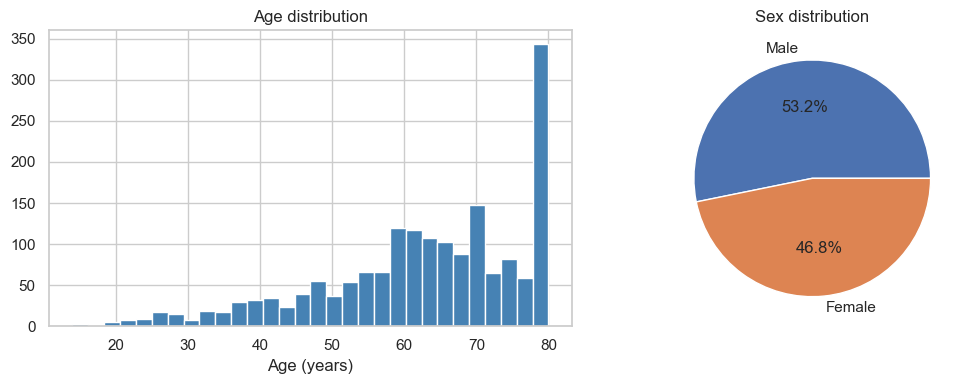

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,1769.0,62.663652,14.425477,1.400000e+01,55.000000,65.000000,74.000000,80.000000
RIAGENDR,1769.0,1.468061,0.499120,1.000000e+00,1.000000,1.000000,2.000000,2.000000
LBXSCR,1769.0,1.137728,0.656363,6.200000e-01,0.910000,1.040000,1.200000,12.740000
eGFR,1769.0,70.437015,15.820439,3.383306e+00,62.215994,73.928701,82.895777,89.996569
DR1TKCAL,1769.0,2022.277558,965.998299,3.000000e+00,1353.000000,1846.000000,2529.000000,8369.000000
DR1TPROT,1769.0,75.926557,40.404781,1.000000e-02,47.850000,68.730000,95.470000,216.240000
DR1TSODI,1769.0,3241.588875,1680.958572,2.300000e+01,2048.000000,2888.000000,4086.000000,9030.040000
DR1TPOTA,1769.0,2498.916880,1223.413089,6.000000e+00,1591.000000,2312.000000,3159.000000,6556.720000
DR1TPHOS,1769.0,1279.165698,646.612226,8.000000e+00,804.000000,1174.000000,1628.000000,3374.840000
DR2TKCAL,1557.0,1885.310212,881.627418,5.397605e-79,1277.000000,1778.000000,2364.000000,8860.000000


In [8]:

print("Missing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20).to_string())

print("\nPatients per CKD stage:")
print(df["CKD_stage"].value_counts(dropna=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pd.to_numeric(df["RIDAGEYR"], errors="coerce").dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")

sex = pd.to_numeric(df["RIAGENDR"], errors="coerce").map({1.0: "Male", 2.0: "Female"}).fillna("Missing")
sex.value_counts().plot.pie(ax=axes[1], autopct="%1.1f%%", title="Sex distribution")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

num_cols = [c for c in df.columns if c not in ("SEQN", "CKD_stage") and pd.api.types.is_numeric_dtype(df[c])]
display(df[num_cols].describe().T)


## Section 3 — Nutrient distribution analysis


           count         mean          std           min      25%      50%      75%       max
DR1TPOTA  1769.0  2498.916880  1223.413089  6.000000e+00  1591.00  2312.00  3159.00  6556.720
DR1TPHOS  1769.0  1279.165698   646.612226  8.000000e+00   804.00  1174.00  1628.00  3374.840
DR1TPROT  1769.0    75.926557    40.404781  1.000000e-02    47.85    68.73    95.47   216.240
DR1TSODI  1769.0  3241.588875  1680.958572  2.300000e+01  2048.00  2888.00  4086.00  9030.040
DR2TPOTA  1769.0  2455.540057  1158.735479  5.397605e-79  1648.00  2271.00  3147.00  6148.520
DR2TPHOS  1769.0  1242.168886   605.503689  5.397605e-79   818.00  1148.00  1588.00  3260.320
DR2TPROT  1769.0    74.554934    38.150649  5.397605e-79    48.39    68.12    94.00   208.296
DR2TSODI  1769.0  3070.453363  1576.349860  1.200000e+01  1950.00  2810.00  3873.00  8632.000


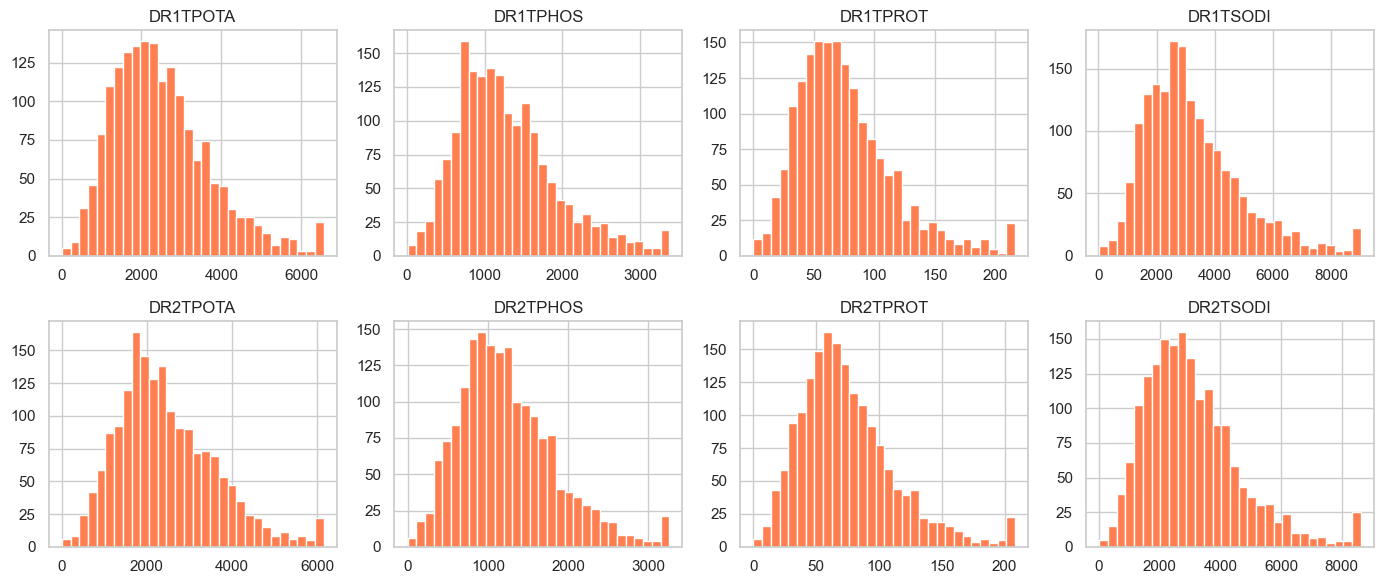

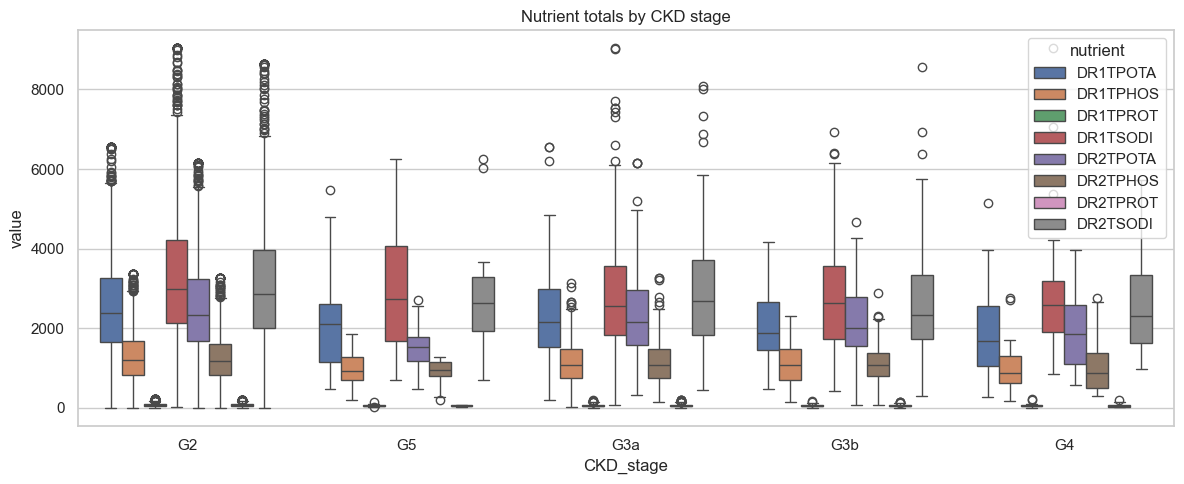

In [9]:

nutrients = [
    "DR1TPOTA", "DR1TPHOS", "DR1TPROT", "DR1TSODI",
    "DR2TPOTA", "DR2TPHOS", "DR2TPROT", "DR2TSODI",
]
nutrients = [c for c in nutrients if c in df.columns]

print(df[nutrients].describe().T.to_string())

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i, c in enumerate(nutrients):
    axes[i].hist(pd.to_numeric(df[c], errors="coerce").dropna(), bins=30, color="coral", edgecolor="white")
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

long = df.melt(id_vars=["CKD_stage"], value_vars=nutrients, var_name="nutrient", value_name="value")
plt.figure(figsize=(12, 5))
sns.boxplot(data=long, x="CKD_stage", y="value", hue="nutrient")
plt.title("Nutrient totals by CKD stage")
plt.tight_layout()
plt.show()


### Observations (nutrients)

- Compare spread and skew across stages.
- Watch NHANES sentinel/missing patterns in raw exports.


## Section 4 — Correlation analysis


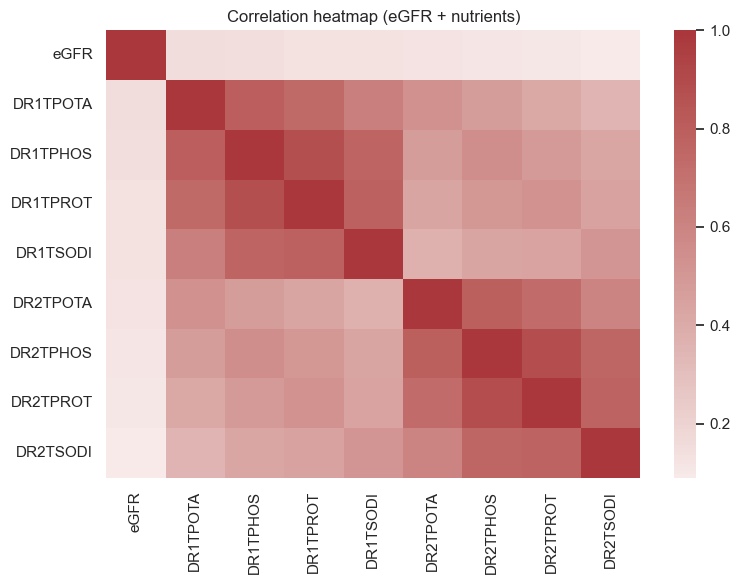

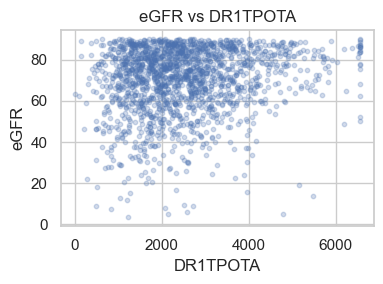

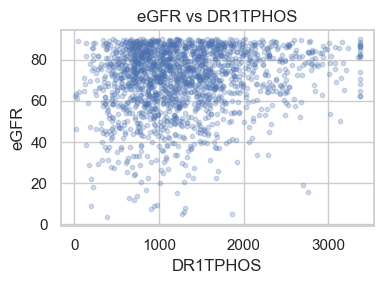

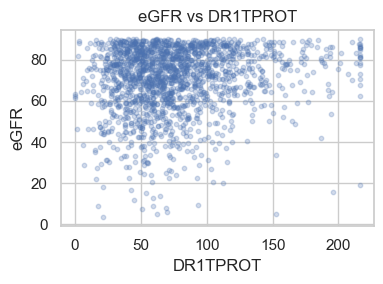

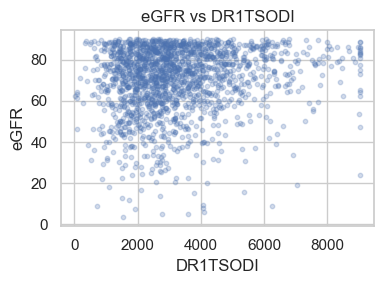

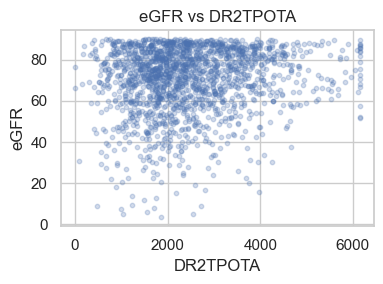

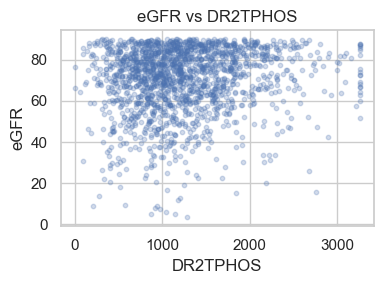

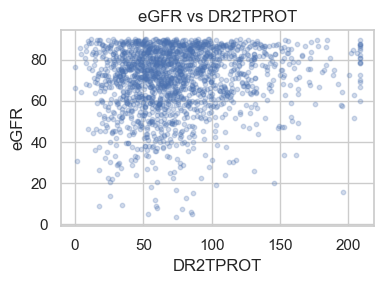

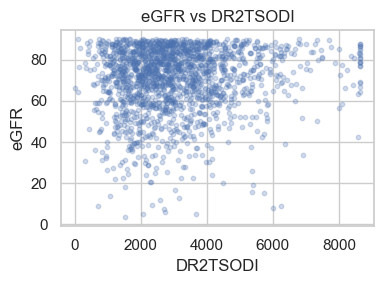

Nutrients most correlated with eGFR (absolute):
DR1TPOTA    0.150474
DR1TPHOS    0.148397
DR1TPROT    0.132474
DR1TSODI    0.132088
DR2TPOTA    0.122181
DR2TPHOS    0.113825
DR2TPROT    0.105467
DR2TSODI    0.089668


In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feat = ["eGFR"] + nutrients
feat = [c for c in feat if c in df.columns]
corr = df[feat].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Correlation heatmap (eGFR + nutrients)")
plt.tight_layout()
plt.show()

eg = pd.to_numeric(df["eGFR"], errors="coerce")
for c in nutrients:
    plt.figure(figsize=(4, 3))
    plt.scatter(pd.to_numeric(df[c], errors="coerce"), eg, alpha=0.25, s=10)
    plt.xlabel(c)
    plt.ylabel("eGFR")
    plt.title(f"eGFR vs {c}")
    plt.tight_layout()
    plt.show()

corr_eg = corr["eGFR"].drop(labels=["eGFR"]).abs().sort_values(ascending=False)
print("Nutrients most correlated with eGFR (absolute):")
print(corr_eg.head(8).to_string())


### Observations (correlations)

- eGFR should correlate inversely with creatinine-driven severity patterns; dietary correlations are ecological at the person level.


## Section 5 — Day 1 vs Day 2 comparison


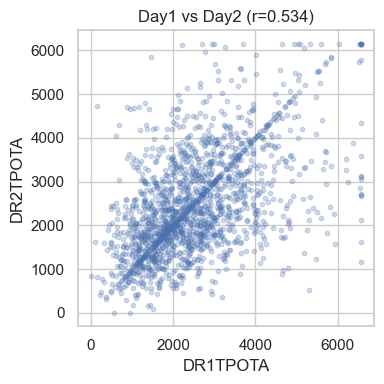

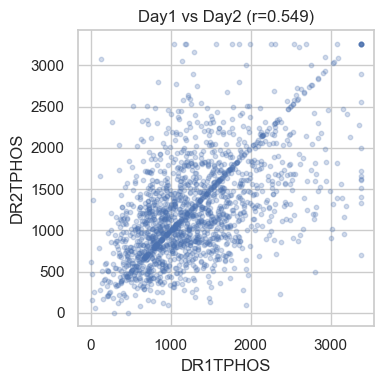

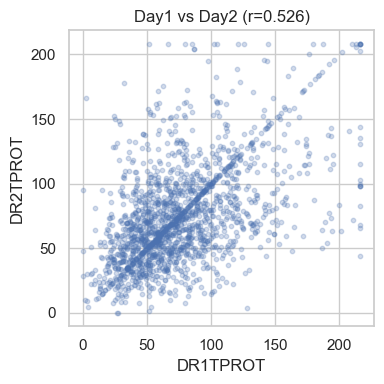

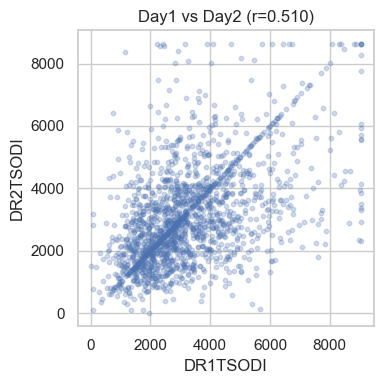

       nutrient_pair  pearson_r
DR1TPOTA vs DR2TPOTA   0.534285
DR1TPHOS vs DR2TPHOS   0.548663
DR1TPROT vs DR2TPROT   0.525746
DR1TSODI vs DR2TSODI   0.510260


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pairs = [
    ("DR1TPOTA", "DR2TPOTA"),
    ("DR1TPHOS", "DR2TPHOS"),
    ("DR1TPROT", "DR2TPROT"),
    ("DR1TSODI", "DR2TSODI"),
]
pairs = [(a, b) for a, b in pairs if a in df.columns and b in df.columns]

rows = []
for d1, d2 in pairs:
    x = pd.to_numeric(df[d1], errors="coerce")
    y = pd.to_numeric(df[d2], errors="coerce")
    m = x.notna() & y.notna()
    r = float(x[m].corr(y[m])) if m.sum() > 2 else float("nan")
    rows.append({"nutrient_pair": f"{d1} vs {d2}", "pearson_r": r})
    plt.figure(figsize=(4, 4))
    plt.scatter(x, y, alpha=0.25, s=10)
    plt.xlabel(d1)
    plt.ylabel(d2)
    plt.title(f"Day1 vs Day2 (r={r:.3f})")
    plt.tight_layout()
    plt.show()

print(pd.DataFrame(rows).to_string(index=False))


### Observations (Day 1 vs Day 2)

- 24-hour recalls are noisy; same-person day-to-day scatter is expected.
- Strong correlation suggests stable reporting; weak correlation suggests high intra-person variability.


## Section 6 — Risk label creation

**HIGH (1)** if the Day 1 / Day 2 combined mean shows **either**:

- **≥ 2 nutrients** above the stage-specific target (K, P, protein, sodium), or  
- **Any one nutrient** more than **50% above** its stage target (i.e. intake > 1.5 × threshold).

Thresholds come from `config.DIETARY_RISK_THRESHOLDS` (KDOQI 2020, KDIGO 2024, NKF–style targets).


Risk label distribution:
risk_label
1    976
0    793


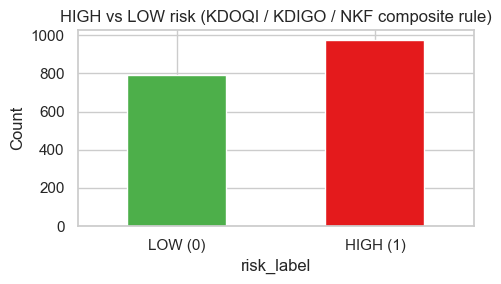

<Figure size 700x300 with 0 Axes>

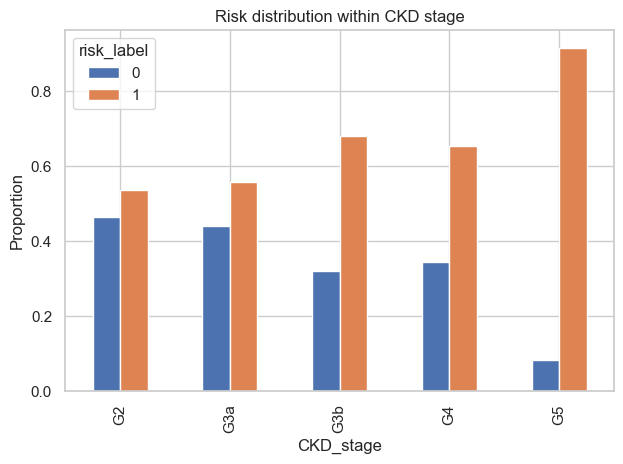

Nutrient threshold violations (row counts; Day1/2 mean > stage threshold):
K      333
P      936
Pr     581
Na    1262
Class imbalance ratio HIGH:LOW = 976:793 (55.17% positive)
HIGH/LOW ratio = 1.231


In [12]:

import sys
from pathlib import Path

def project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "config.py").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Run from the GUIDAPLATE repo (config.py not found).")

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "app") not in sys.path:
    sys.path.insert(0, str(ROOT / "app"))

import importlib
import config
importlib.reload(config)
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def combine_day12(frame: pd.DataFrame, c1: str, c2: str) -> pd.Series:
    a = pd.to_numeric(frame[c1], errors="coerce")
    b = pd.to_numeric(frame[c2], errors="coerce")
    return pd.concat([a, b], axis=1).mean(axis=1, skipna=True)


x = df.copy()
x["K"] = combine_day12(x, "DR1TPOTA", "DR2TPOTA")
x["P"] = combine_day12(x, "DR1TPHOS", "DR2TPHOS")
x["Pr"] = combine_day12(x, "DR1TPROT", "DR2TPROT")
x["Na"] = combine_day12(x, "DR1TSODI", "DR2TSODI")


def thr_series(stage_series: pd.Series, key: str) -> pd.Series:
    return stage_series.map(
        lambda s: float(config.DIETARY_RISK_THRESHOLDS.get(str(s), {}).get(key, float("nan")))
    )


thr_k = thr_series(x["CKD_stage"], "potassium")
thr_p = thr_series(x["CKD_stage"], "phosphorus")
thr_pr = thr_series(x["CKD_stage"], "protein")
thr_na = thr_series(x["CKD_stage"], "sodium")

# Valid comparisons: observed mean and stage threshold both present
vk = x["K"].notna() & thr_k.notna()
vp = x["P"].notna() & thr_p.notna()
vpr = x["Pr"].notna() & thr_pr.notna()
vna = x["Na"].notna() & thr_na.notna()

viol_k = vk & (x["K"] > thr_k)
viol_p = vp & (x["P"] > thr_p)
viol_pr = vpr & (x["Pr"] > thr_pr)
viol_na = vna & (x["Na"] > thr_na)

n_over = (
    viol_k.astype(int)
    + viol_p.astype(int)
    + viol_pr.astype(int)
    + viol_na.astype(int)
)
multi_high = n_over >= 2
severe_single = (
    (vk & (x["K"] > thr_k * 1.5))
    | (vp & (x["P"] > thr_p * 1.5))
    | (vpr & (x["Pr"] > thr_pr * 1.5))
    | (vna & (x["Na"] > thr_na * 1.5))
)
x["risk_label"] = (multi_high | severe_single).astype(int)

cause = pd.DataFrame({"K": viol_k, "P": viol_p, "Pr": viol_pr, "Na": viol_na})
cause_counts = cause.sum(axis=0)

print("Risk label distribution:")
print(x["risk_label"].value_counts(dropna=False).to_string())

plt.figure(figsize=(5, 3))
x["risk_label"].value_counts().sort_index().plot(kind="bar", color=["#4daf4a", "#e41a1c"])
plt.xticks([0, 1], ["LOW (0)", "HIGH (1)"], rotation=0)
plt.title("HIGH vs LOW risk (KDOQI / KDIGO / NKF composite rule)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
pd.crosstab(x["CKD_stage"], x["risk_label"], normalize="index").plot(kind="bar", stacked=False)
plt.title("Risk distribution within CKD stage")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

print("Nutrient threshold violations (row counts; Day1/2 mean > stage threshold):")
print(cause_counts.to_string())

pos = int(x["risk_label"].sum())
neg = int(len(x) - pos)
ratio = (pos / neg) if neg else float("inf")
print(f"Class imbalance ratio HIGH:LOW = {pos}:{neg} ({pos/len(x):.2%} positive)")
if neg:
    print(f"HIGH/LOW ratio = {ratio:.3f}")


## Section 7 — Key findings summary

1. **Data quality**: inspect missingness in dietary recalls; Day 2 often sparser than Day 1.
2. **Stage mix**: CKD cohort composition drives downstream model class balance.
3. **Nutrient skew**: long right tails are common; consider transforms for some ML models.
4. **Day-to-day variability**: Day1 vs Day2 scatter informs whether sequence models add value.
5. **Rule-based risk**: threshold labels are intentionally simple baselines for comparison with ML.

**Modeling recommendations**: stratify by stage, report calibration, and compare against rule baselines.
